Import libraries

In [16]:
import pandas as pd
import numpy as np
from utilsforecast.evaluation import evaluate
from utilsforecast.plotting import plot_series
from utilsforecast.losses import *
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
import warnings

warnings.filterwarnings("ignore")

Load the dataset

In [17]:
df = pd.read_csv("/home/leonie/Downloads/TimeSeriesAnalysis/data/daily_sales_french_bakery.csv", parse_dates=["ds"])
# Filter the series that has more than 28 time sets
df = df.groupby("unique_id").filter(lambda x:len(x) >=28)
#Drop the unit_price feature
df = df.drop("unit_price", axis=1)
# Preview the dataset
df.head()

## unique_id :  french bakery
##  ds : Datetime sale
## y :  the volume of sales for a particular product.

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


In [18]:
df["unique_id"].value_counts(normalize=True)

unique_id
BAGUETTE              0.011194
BOULE 400G            0.011194
BANETTE               0.011194
BOULE 200G            0.011194
BANETTINE             0.011194
                        ...   
RELIGIEUSE            0.001248
SABLE F  P            0.001195
DELICETROPICAL        0.001107
VIENNOISE             0.001072
PAIN SUISSE PEPITO    0.000896
Name: proportion, Length: 121, dtype: float64

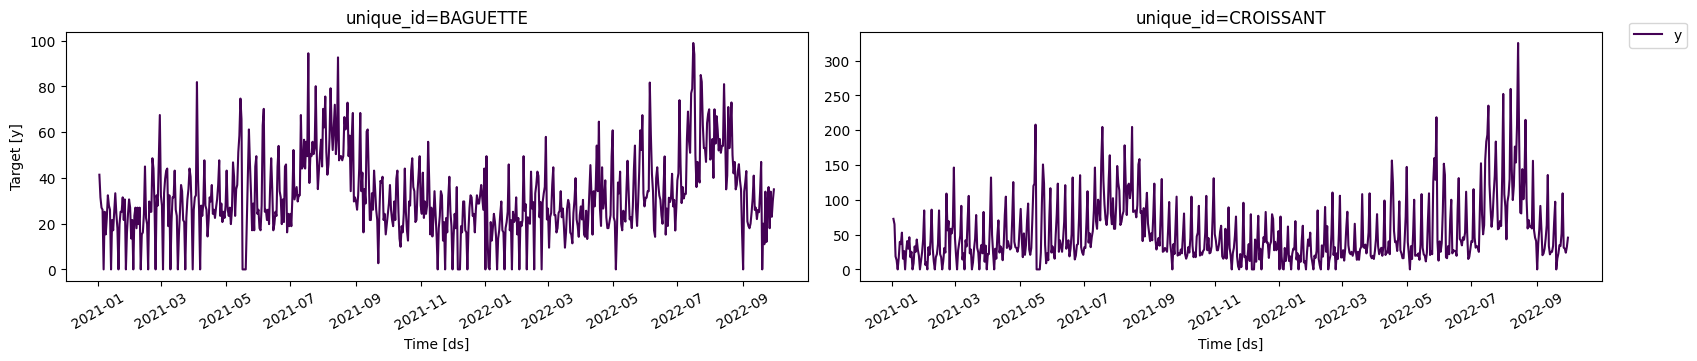

In [19]:
# Plot the series of two products
plot_series(df=df, ids=["BAGUETTE", "CROISSANT"], palette="viridis")

The values of the "BAGUETTE" oscillate between zero and 100 while CROISSANT values oscillate between 0 and 300.

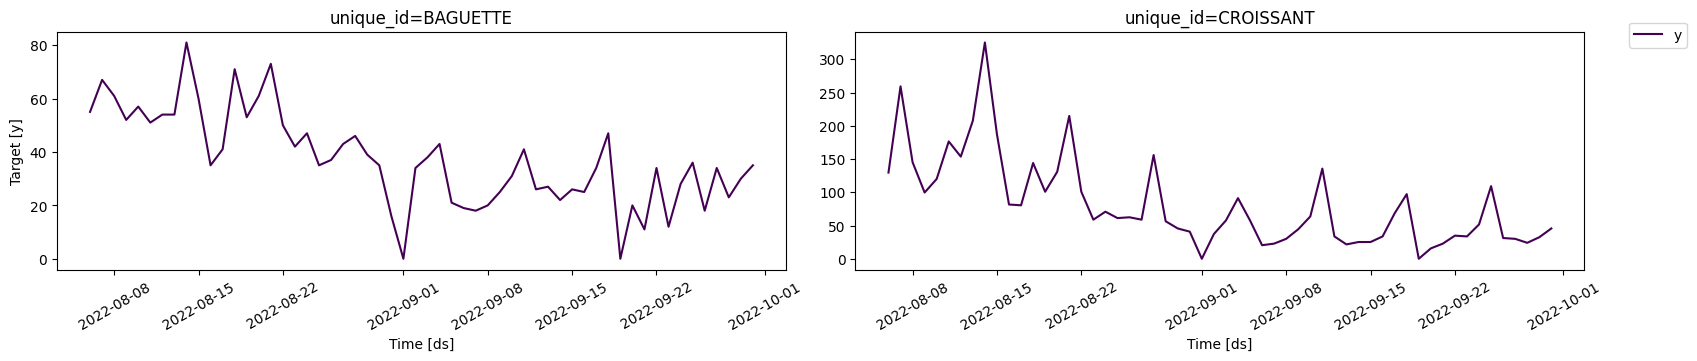

In [20]:
# Let plot the last 56 time sets.
plot_series(df=df, max_insample_length=56, ids=["BAGUETTE", "CROISSANT"], palette="viridis")

Baseline Models

In [21]:
horizon = 7

models = [
    Naive(), # Forecast the last known time sets
    HistoricAverage(), # Take the average of the entire history of our series and use that value as a forecast
    WindowAverage(window_size=7), # How many time steps you want to take into account to calculate that average and then forecast that value
    SeasonalNaive(season_length=7) # We need to set seasonal length
]

# Instantiate the models and precise the different models to train
# And specify the frequency of your data which is daily in our case D
sf = StatsForecast(models=models, freq="D")
# Train the model on the data
sf.fit(df=df)
preds = sf.predict(h=horizon)
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0


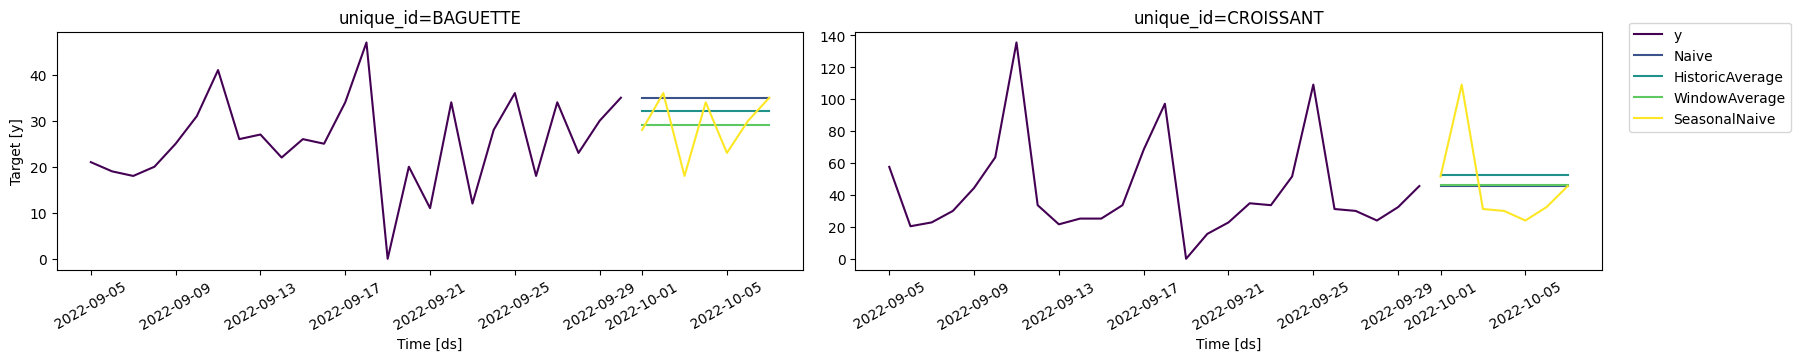

In [22]:
# Plot our prediction
plot_series(
    df=df,
    forecasts_df=preds,
    ids=["BAGUETTE", "CROISSANT"],
    max_insample_length=26,
    palette="viridis"
)

Evaluate the baseline models

In [23]:
# Split the dataset into train and test datasets
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [24]:
# Fit the model on the training dataset
sf.fit(df=train)
preds = sf.predict(h=horizon)

In [25]:
# Create the evalution DataFrame
eval_df = pd.merge(
    test,
    preds,
    on=["ds", "unique_id"]
)

In [26]:
eval_df.head()

,unique_id,ds,y,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-22,0.0,0.0,9.577465,1.428571,10.0
1,12 MACARON,2022-09-23,0.0,0.0,9.577465,1.428571,0.0
2,12 MACARON,2022-09-24,10.0,0.0,9.577465,1.428571,0.0
3,12 MACARON,2022-09-25,0.0,0.0,9.577465,1.428571,0.0
4,12 MACARON,2022-09-26,0.0,0.0,9.577465,1.428571,0.0


In [33]:
evaluation = evaluate(
    df=eval_df,
    metrics=[mae],
    time_col="ds",
    target_col="y",
    id_col="unique_id"
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421984,6.008163,7.885714


In [34]:
evaluation = evaluation.drop(["unique_id"], axis=1).groupby("metric").mean().reset_index()
evaluation.head()

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636
